TEMP avant envoi vers code

# d'après le chapitre Arima du livre Hyndman

In [57]:
import pandas as pd

######### TEMP ###########
# lecture de steam_prod d'inariz 
# sera enlevé quand on connectera les différents bouts ensemble
from src.ingest import data_workflow

list_df = []
for filename in [
    "inariz_steam_prod_2026-03-09_to_2026-03-12.csv",
    "inariz_steam_prod_2026-03-13_to_2026-03-16.csv",
]:
    df = data_workflow("inariz", "steam_prod", filename)

    # include the unit into the main column name
    df = df.rename(columns={"Valeur": "steam_production_m3_h"})

    list_df.append(df)

steam_prod = pd.concat(list_df, ignore_index=True)

# for other columns, keep only numerical columns
# set the timestamp as a column with a standard name, not as the index
steam_prod = steam_prod.drop(columns=["Unité"])

# target
steam_prod = steam_prod[
    ["measured_at_utc", "steam_production_m3_h"]
]

# Resample correct
# 1. créer les index manquants aux frontières des intervales de 15min
# 2. y copier la valeur précédentes
from src.dataset import add_missing_timestamps_with_previous_value

df_reindexed = add_missing_timestamps_with_previous_value(steam_prod)
df_reindexed[(df_reindexed["measured_at_utc"]>pd.Timestamp(2026, 3, 9, 7, 27, 0, tz= "UTC"))&(df_reindexed["measured_at_utc"]<pd.Timestamp(2026, 3, 9, 9, 8, 0, tz= "UTC"))]


# 3. prendre la valeur constante qui donne la meme aire sous la courbe
from src.dataset import equivalent_constant_rate_on_15min

eq_15min = equivalent_constant_rate_on_15min(
    df_reindexed,
    timestamp_col="measured_at_utc",
    value_col="steam_production_m3_h",
    freq="15min",
)

eq_15min[(eq_15min["bin_start"]>pd.Timestamp(2026, 3, 9, 7, 27, 0, tz= "UTC"))&(eq_15min["bin_start"]<pd.Timestamp(2026, 3, 9, 9, 8, 0, tz= "UTC"))]

# resampled_df
resampled_df = eq_15min[["bin_start", "equivalent_steam_production_m3_h"]].drop_duplicates().dropna().reset_index(drop=True)
resampled_df.head()


,bin_start,equivalent_steam_production_m3_h
0,2026-03-08 23:00:00+00:00,290.441258
1,2026-03-08 23:15:00+00:00,267.124525
2,2026-03-08 23:30:00+00:00,371.020334
3,2026-03-08 23:45:00+00:00,228.311791
4,2026-03-09 00:00:00+00:00,569.235351


In [58]:
# contrôles visuels : 
# le plot de la time serie
# le plot ACF. Pour une série stationnaire, il tombera à 0 assez vite, alors que ça décroiera lentement sinon.
# et pour une série non-stationnaire, la valeur de r_1 est souvent grande et positive.



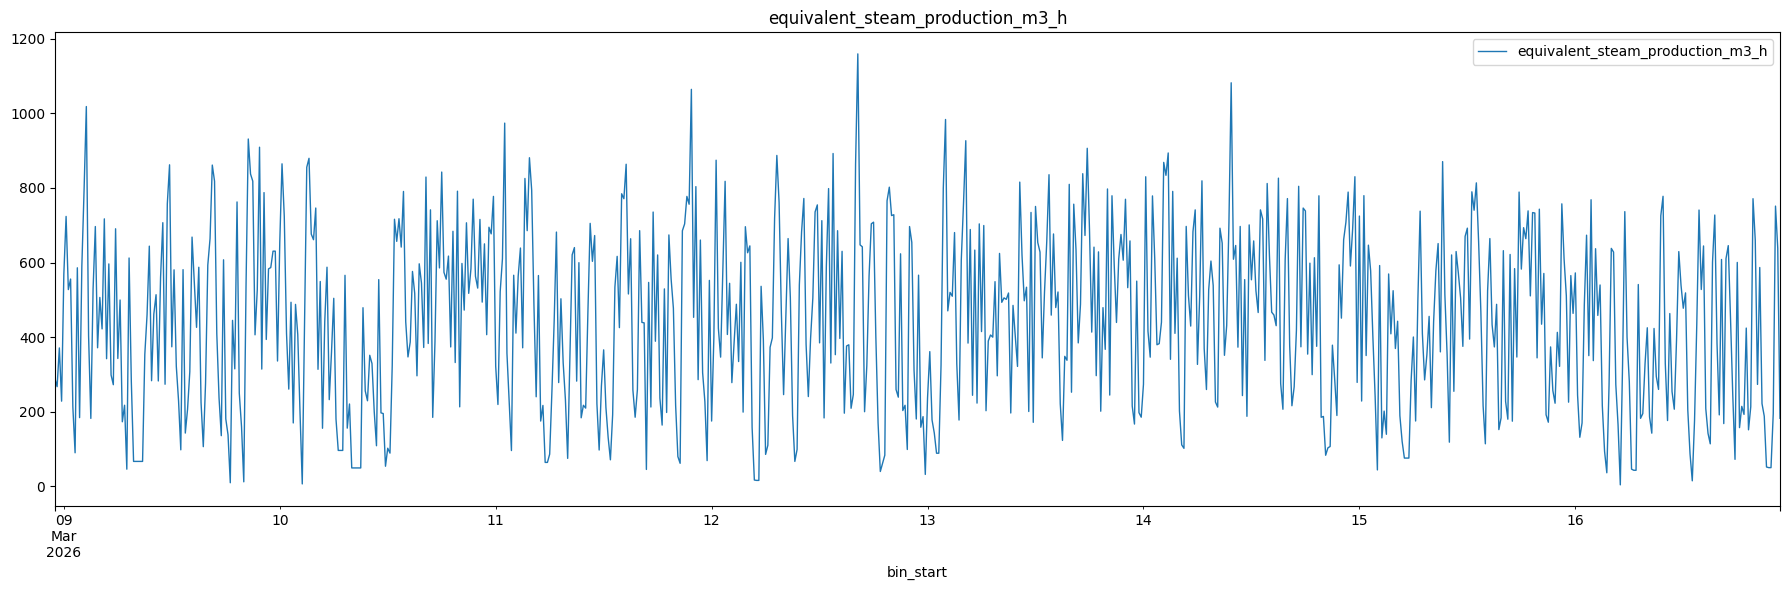

In [59]:
# plot de la time serie

import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

# boiler box
ax = resampled_df.plot("bin_start", y="equivalent_steam_production_m3_h", linewidth=1, ax=ax)
ax.set_title("equivalent_steam_production_m3_h")
ax.set_xlabel("bin_start")

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

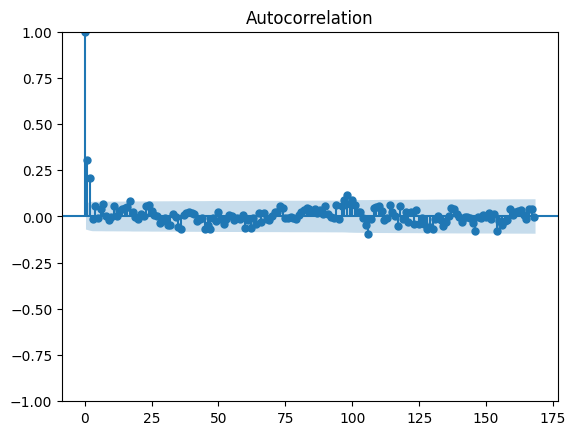

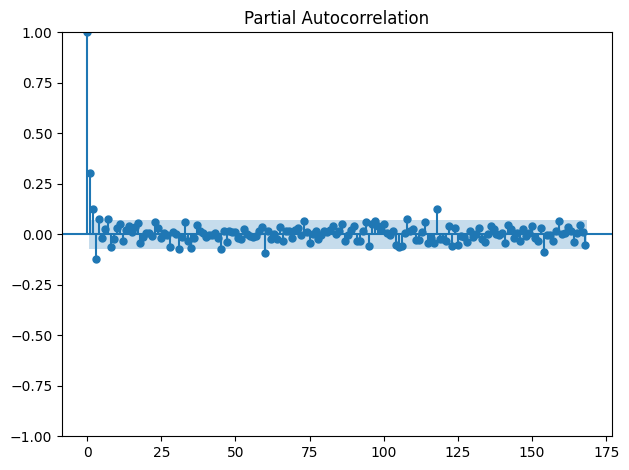

In [60]:
# plot ACF of initial data

from plots import autocorrelation_plot #plot_acf y fait ce que je veux, mais que fait pacf?

autocorrelation_plot(resampled_df, "equivalent_steam_production_m3_h")

# faire la meme chose avec bartlett_confint=False comme dans hyndman?

maintenant qu'on utilise la donnée resampled correctement, je ne sais pas si le plot d'autocorrelation ci-dessus pour les données initiales tend à indiquer qu'on a une série stationnaire ou NON-stationnaire

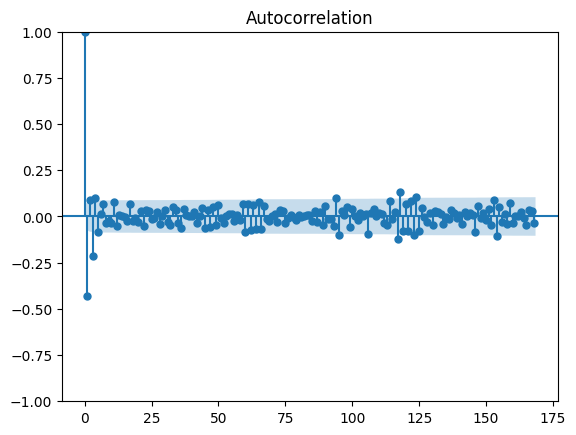

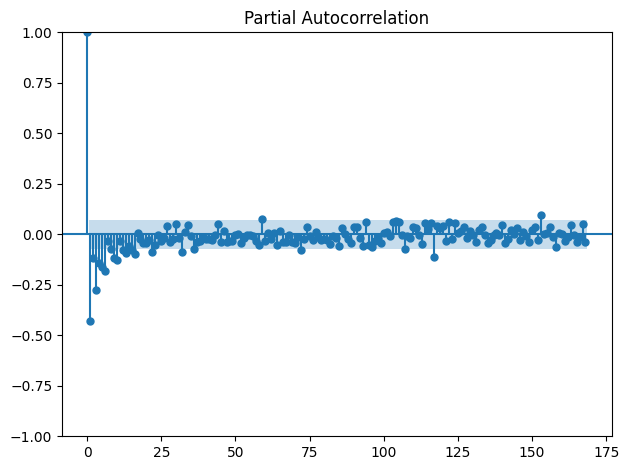

In [61]:
# plot ACF of the differentiated data
steam_prod_diff = resampled_df.copy()
steam_prod_diff["equivalent_steam_production_m3_h"] = steam_prod_diff["equivalent_steam_production_m3_h"].diff()

autocorrelation_plot(steam_prod_diff[1:], "equivalent_steam_production_m3_h")

je ne suis pas sûr de ce que nous dit le plot d'autocorrelation ci-dessus pour la donnée différentiée.
J'ai l'impression qu'on dégrade l'information présente.

In [62]:
# vérification avec la stat de Ljung-Box
# permet de savoir si les points successifs sont aléatoires et indépendants, ou pas.

from statsmodels.stats.diagnostic import acorr_ljungbox

# tester pour plusieurs lags
res = []
for lag in range(1,4*24*7):
    ljung_box = acorr_ljungbox(steam_prod_diff["equivalent_steam_production_m3_h"][1:], lags=[lag])
    res.append(ljung_box)

ljung_box_complet = pd.concat(res)
ljung_box_complet
# si la p-value est très faible, alors il y a correlation

,lb_stat,lb_pvalue
1,140.941181,1.657311e-32
2,147.035091,1.179602e-32
3,182.499779,2.544533e-39
4,190.164562,4.885774e-40
5,195.338705,2.820934e-40
...,...,...
667,1232.451687,3.525417e-36
668,1232.783593,4.448221e-36
669,1233.666160,4.940928e-36
670,1233.836114,6.465795e-36


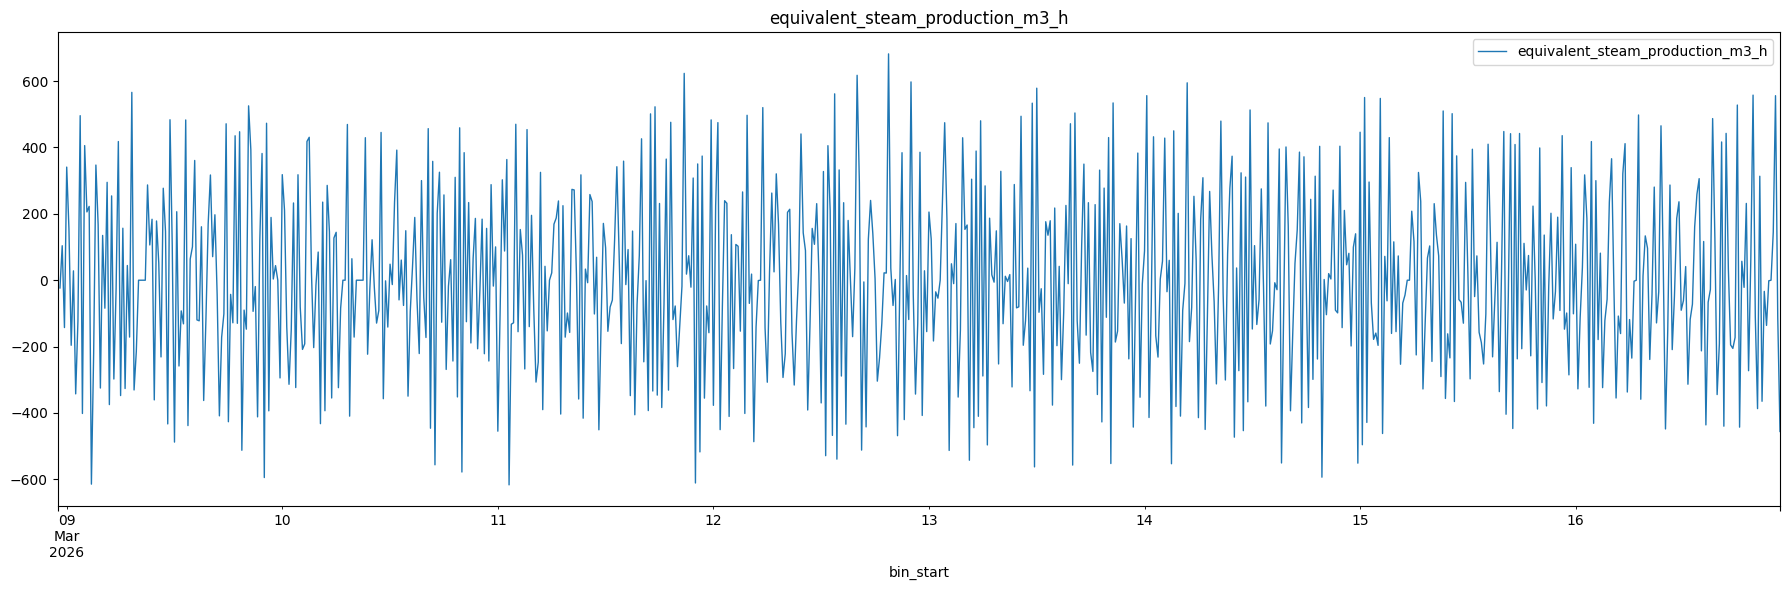

In [63]:
# besoin de faire du second-order differencing ? seul, ou en plus du first-order?
# ou du seasonal differencing ? seul, ou en plus du first order ?

# contrôle visuel de ce que donne la donnée différentiée une fois.
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

ax = steam_prod_diff[:1000].plot("bin_start", y="equivalent_steam_production_m3_h", linewidth=1, ax=ax)
ax.set_title("equivalent_steam_production_m3_h")
ax.set_xlabel("bin_start")

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

peut-être qu'on s'approche du buit blanc ? dur à dire

In [64]:
# unit root test, pour savoir si la donnée est stationnaire, pour tester l'hypothèse de stationnarité
# adf test : augmented dickey fuller test
# Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test (dans livre hyndman)

# kpss for different lag values
from statsmodels.tsa.stattools import kpss
kpss_stat, kpss_pvalue, lags, crit = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags = 5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}") #between 0.01 and 0.1. If less than 0.01, reported as 0.01. If more than 0.1, reported as 0.1. 
#If kpss_pvalue is small (<0.05), the data is not stationary
# if kpss_pvalue is high (>0.1), then the data is stationary
print(lags)
print(crit)

kpss_stat: 0.227
kpss_pvalue: 0.10
5
{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\830161483.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, lags, crit = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags = 5)


for kpss, the high p value indicates that there is stationarity.

In [65]:

# kpss of the differenced data
kpss_stat, kpss_pvalue, *_ = kpss(steam_prod_diff["equivalent_steam_production_m3_h"][1:], nlags = 5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}") #between 0.01 and 0.1. If less than 0.01, reported as 0.01. If more than 0.1, reported as 0.1. 
#If kpss_pvalue is small (<0.05), the data is not stationary



kpss_stat: 0.007
kpss_pvalue: 0.10


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\2074549720.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(steam_prod_diff["equivalent_steam_production_m3_h"][1:], nlags = 5)


In [66]:
# do the successive kpss alone, and return the number of appropriate first differences:
from statsforecast.arima import ndiffs
ndiffs(resampled_df["equivalent_steam_production_m3_h"].to_numpy())



0

In [67]:
# quick way to verify apples to apples, from codex
import math
import numpy as np
import statsmodels.api as sm
from statsforecast.arima import ndiffs

x = resampled_df["equivalent_steam_production_m3_h"].to_numpy()

print("ndiffs:", ndiffs(x))
nl0 = math.floor(3 * math.sqrt(len(x)) / 13)
print("kpss level (same lag rule):", sm.tsa.kpss(x, "c", nlags=nl0)[1])

xd = np.diff(x)
nl1 = math.floor(3 * math.sqrt(len(xd)) / 13)
print("kpss diff1 (same lag rule):", sm.tsa.kpss(xd, "c", nlags=nl1)[1])

ndiffs: 0
kpss level (same lag rule): 0.1
kpss diff1 (same lag rule): 0.1


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\971141596.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("kpss level (same lag rule):", sm.tsa.kpss(x, "c", nlags=nl0)[1])
C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\971141596.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("kpss diff1 (same lag rule):", sm.tsa.kpss(xd, "c", nlags=nl1)[1])


ndiffs confirme ce que j'ai trouvé seul : aucune différenciation nécessaire pour avoir une série stationnaire.
ce n'était pas le cas quand j'utilisais la série avant resmapling correct

In [68]:
## je continue l'apple to apple, adapté moi meme : 
# nlags calculés par moi meme, et kpss utilisé comme initialement. 
# J'obtiens 0.1 cette fois ?
x = resampled_df["equivalent_steam_production_m3_h"].to_numpy()
nl0 = math.floor(3 * math.sqrt(len(x)) / 13)

kpss_stat, kpss_pvalue, *_ = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags = nl0)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}") #between 0.01 and 0.1. If less than 0.01, reported as 0.01. If more than 0.1, reported as 0.1. 
#If kpss_pvalue is small (<0.05), the data is not stationary

kpss_stat: 0.221
kpss_pvalue: 0.10


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\2056730205.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags = nl0)


In [69]:
# je ne comprends pas le choix de nlags par hyndman, mais je peux appeler kpss avec la vlaeur par défaut nlags auto
kpss_stat, kpss_pvalue, lags, crit = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags="auto")
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}") #between 0.01 and 0.1. If less than 0.01, reported as 0.01. If more than 0.1, reported as 0.1. 
#If kpss_pvalue is small (<0.05), the data is not stationary
print(lags)
print(crit)

kpss_stat: 0.205
kpss_pvalue: 0.10
9
{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\2274007656.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, lags, crit = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags="auto")


In [70]:
# etudier l'évolution des résultats de kpss en fonction des lags
nl0 = math.floor(3 * math.sqrt(len(x)) / 13)
nl0


kpss_results = []
for nlags in range(55):
    results = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags=nlags)
    kpss_results.append(results)

kpss_results_df = pd.DataFrame(kpss_results, columns=["kpss_stat", "p_value", "lags", "crit"] )
kpss_results_df
#{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\2830344179.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  results = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags=nlags)
C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\2830344179.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  results = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags=nlags)
C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_42076\2830344179.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  results = kpss(resampled_df["equivalent_steam_production_m3_h"], nlags=nlags)
C:\Users\Loris Amabile\AppData\Loc

,kpss_stat,p_value,lags,crit
0,0.411417,0.072234,0,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
1,0.315090,0.100000,1,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
2,0.266153,0.100000,2,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
3,0.247972,0.100000,3,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
4,0.234985,0.100000,4,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
5,0.227301,0.100000,5,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
6,0.220650,0.100000,6,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
7,0.213947,0.100000,7,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
8,0.208927,0.100000,8,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
9,0.205423,0.100000,9,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."


le choix de nlags change la pvalue de kpss, mais maintenant que j'utilise une série resamplée correctement, ça ne change pas presque rien.

1. comprendre le choix de 5 comme nlags par hyndman
2. est ce que je peux changer le nlags de ndiffs de statsforecast? => non
3. quel est l'impact des lags dans kpss? 
- plus de lags ajoute des termes d'autocovariance dans l'estimateur de la variance
- plus on rajoute de lags, plus on augmente l'estimateur de la variance, plus on va probablement diminuer la valeur de la stat et augmenter la pvalue, plus on accepter la stationnarité.
- si on prend peu de lags, on sous estime la variance longterme, on rejette trop souvent l'hypothèse de stationarité.

LM : lagrange multiplier
LBI : locally best invariant


ADF

In [71]:
# adf # augmented dickey fullre # for different lag values ??
from statsmodels.tsa.stattools import adfuller
adfuller_stat, adfuller_pvalue, usedlag, nobs, critical_values, *_ = adfuller(resampled_df["equivalent_steam_production_m3_h"])
print(f"adfuller_stat: {adfuller_stat:.3f}")
print(f"adfuller_pvalue: {adfuller_pvalue}") 
#between 0 and 1. If <= 0.05, then strong evidence that data is stationary
print(f"usedlag: {usedlag:.3f}")
print(f"nobs: {nobs:.3f}")

print('Critical Values:')
    #labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
for key, value in critical_values.items():
    print('\t%s: %.3f' % (key, value))

# check of the very small value
print(repr(adfuller_pvalue))
print(f"{adfuller_pvalue:.20e}")



adfuller_stat: -8.696
adfuller_pvalue: 3.9142441056560134e-14
usedlag: 7.000
nobs: 760.000
Critical Values:
	1%: -3.439
	5%: -2.865
	10%: -2.569
np.float64(3.9142441056560134e-14)
3.91424410565601342393e-14


if the p value i still displayed as 0, it means that it is even smaller than machine/reporting precision.

for ADF, the small p-value suggests there IS stationarity.


In [72]:
# adf of the differenced data
adfuller_stat, adfuller_pvalue, usedlag, nobs, critical_values, *_ = adfuller(steam_prod_diff["equivalent_steam_production_m3_h"][1:])
print(f"adfuller_stat: {adfuller_stat:.3f}")
print(f"adfuller_pvalue: {adfuller_pvalue}") #between 0 and 1. If <= 0.05, then strong evidence that data is stationary
print(f"usedlag: {usedlag:.3f}")
print(f"nobs: {nobs:.3f}")

print('Critical Values:')
    #labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
for key, value in critical_values.items():
    print('\t%s: %.3f' % (key, value))

# check of the very small value
print(repr(adfuller_pvalue))
print(f"{adfuller_pvalue:.20e}")

adfuller_stat: -12.326
adfuller_pvalue: 6.589037851038581e-23
usedlag: 15.000
nobs: 751.000
Critical Values:
	1%: -3.439
	5%: -2.865
	10%: -2.569
np.float64(6.589037851038581e-23)
6.58903785103858131092e-23


Pour la série initiale comme pour la série différentiée ci dessus, maintenant qu'on utilise une série resamplée correctement, on a le test kpss qui valide l'hypothèse de stationnarité, et le test adf qui la valide l'hypothèse de unit root, ce qui laisse la place à la stationnarité.
Donc en effet on peut être bien stationnaire avec la série initiale comme avec la série différentiée !

ce n'était pas le cas quand j'utilisais la série avant resampling correct.

In [73]:
# # do the successive ?? alone, and return the number of appropriate seasonal differences
# # based on the seasonal strength
# from statsforecast.arima import nsdiffs
# # Test for seasonal differencing
# nsdiffs(resampled_df["equivalent_steam_production_m3_h"], period=12)
# # nous on peut tester avec ces périodes_là : un jour (on n'a pas une semaine dans ce dataset limité chargé ici) 

# je ne fais meme pas le seasonal differencing avec nsdiffs, car d'après mon test KPSS avec les lags qu'on m'impose, j'ai déjà de la stationnarité !


In [74]:
# modèles de base à faire et évaluer : autorégression simple, et moving average simple

In [86]:
# rename columns for this function
resampled_df_autoarima = resampled_df.copy()
resampled_df_autoarima = resampled_df_autoarima.rename(columns={"bin_start":"ds","equivalent_steam_production_m3_h":"y"})
resampled_df_autoarima["unique_id"] = "inariz_steam" 

# utiliser AutoARIMA() de statsforecast décidera tout seul des valeurs de p, d, q à choisir

from statsforecast.arima import ARIMASummary
from statsforecast.models import ARIMA, AutoARIMA
from statsforecast import StatsForecast

models = [AutoARIMA(allowmean=True)]
sf = StatsForecast(models=models, freq="15min", n_jobs=-1)
sf.fit(df=resampled_df_autoarima)

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs["mean"] = coefs.pop("intercept")
coefs = {k: round(v, 3) for k, v in coefs.items()}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(1,0,2) with non-zero mean 

      Coefficients
ar1         -0.437
ma1          0.729
ma2          0.328
mean       442.707 

          Metrics
sigma^2  49557.36
loglik   -5239.22
aic      10488.45
aicc     10488.53
bic      10511.67


standard deviation (sigma) is huge.

In [77]:
# plot result of the autoarima search
levels = [80, 95]
fc = sf.predict(h=96, level=levels)

fc.tail()


,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95
91,inariz_steam,2026-03-17 21:45:00+00:00,442.707355,-22.135097,138.763213,746.651498,907.549808
92,inariz_steam,2026-03-17 22:00:00+00:00,442.707355,-22.135097,138.763213,746.651498,907.549808
93,inariz_steam,2026-03-17 22:15:00+00:00,442.707355,-22.135097,138.763213,746.651498,907.549808
94,inariz_steam,2026-03-17 22:30:00+00:00,442.707355,-22.135097,138.763213,746.651498,907.549808
95,inariz_steam,2026-03-17 22:45:00+00:00,442.707355,-22.135097,138.763213,746.651498,907.549808


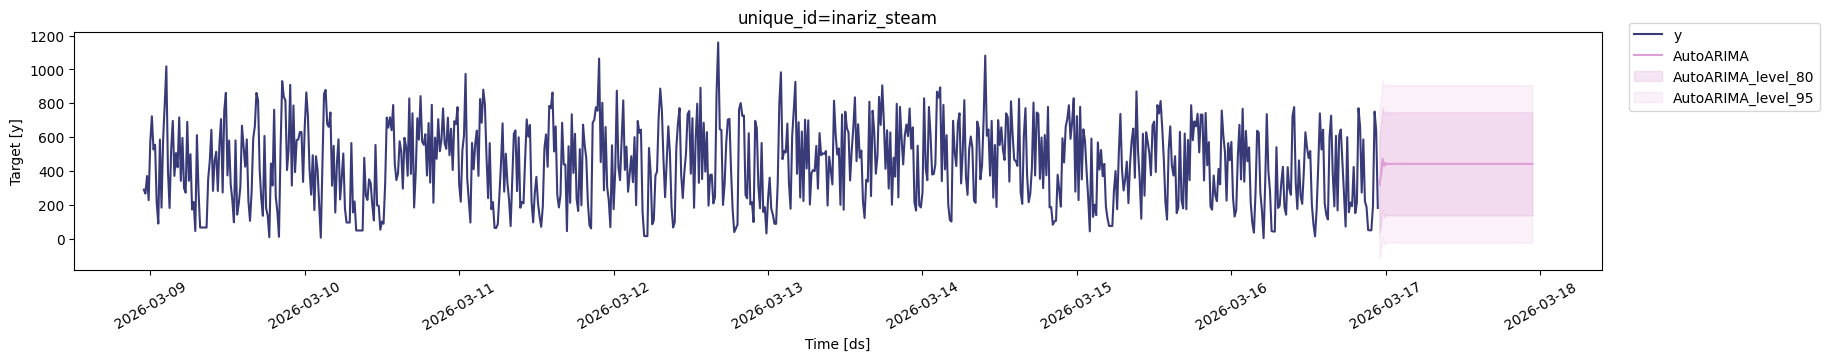

In [ ]:
sf.plot(resampled_df_autoarima, fc, level=[80, 95])

In [88]:
# utiliser plus de modèles pour chercher :


models = [
    AutoARIMA(allowmean=True, alias="stepwise"),
    AutoARIMA(stepwise=False, alias="search"), #works harder to search a larger model space
    ARIMA(order=(4, 0, 0), alias="arima400"), # PCAF says AR(4)
    ARIMA(order=(0, 0, 3), alias="arima003") # ACF says MA(3)
        ]
sf = StatsForecast(models=models, freq="15min", n_jobs=-1)
sf.fit(df=resampled_df_autoarima)

summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,search,"ARIMA(0,0,4) with non-zero mean",49472.794728,-5238.068606,10488.137213,10488.247594,10515.999951
1,stepwise,"ARIMA(1,0,2) with non-zero mean",49557.355853,-5239.223314,10488.446627,10488.525368,10511.665576
2,arima400,"ARIMA(4,0,0) with non-zero mean",49574.316661,-5238.847477,10489.694954,10489.805335,10517.557692
3,arima003,"ARIMA(0,0,3) with non-zero mean",49789.775684,-5241.005135,10492.010269,10492.089009,10515.229218


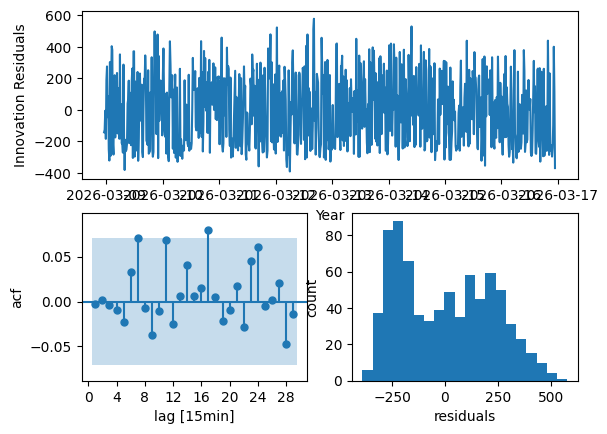

In [99]:
# plot the residuals of the best model, to check if they look like white noise

from matplotlib.ticker import MaxNLocator
from statsmodels.graphics.tsaplots import plot_acf

fc = sf.forecast(df=resampled_df_autoarima, h=96, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["search"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(resampled_df_autoarima["ds"], residuals)
axes["resid"].set(xlabel="Year", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [15min]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

Oui, ça ressemble bien à du bruit blanc

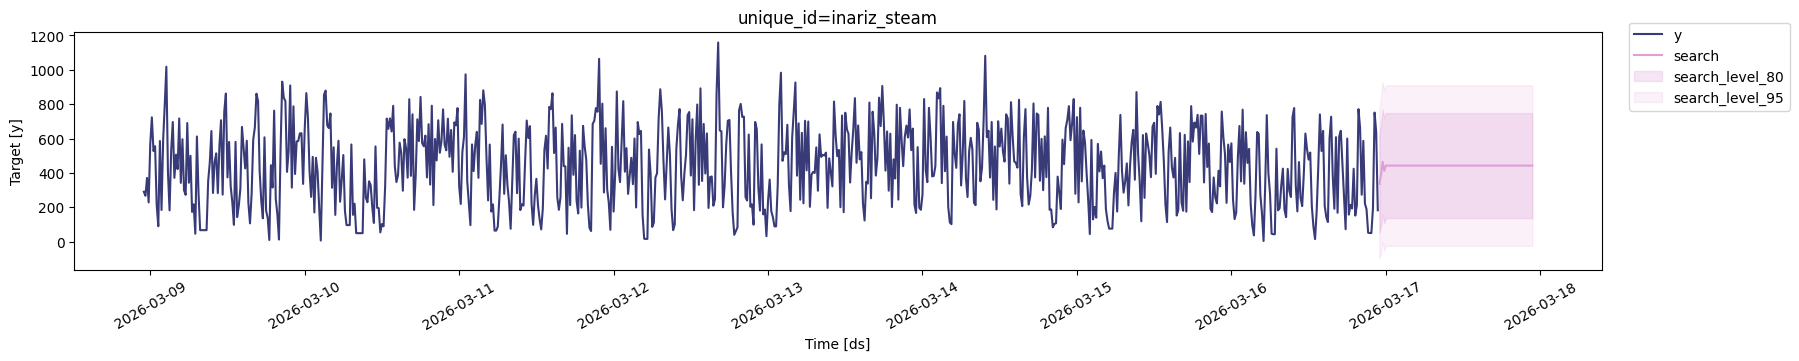

In [ ]:
# plot du forecast donné par le modèle "search", ARIMA(0,0,4)

search_columns = fc.columns[fc.columns.str.startswith("search")]
search_fc = fc[["unique_id", "ds", *search_columns]]

sf.plot(resampled_df_autoarima, search_fc, level=[80, 95])

# plot_series(caf_economy, search_fc, level=[80, 95],
#     xlabel="Year", ylabel="Exports",
#     title="Central African Republic exports",
#     palette="black_and_blue", rm_legend=False,
#     legend_loc="outside lower center")

Is is possible that the mean forecast are very similar to what we would get with a random walk model (ARIMA(0,1,0)). But the prediction interval should (todo check) be much narrower.

In [101]:
# portemanteau test to check if the residuals are white noise?
ljung_box = acorr_ljungbox(residuals, lags=[96], model_df=4) # 4 = p+q = 0+4
ljung_box
# large p-value => also suggesting that the residuals are white noise.

,lb_stat,lb_pvalue
96,82.908999,0.740229


La recherche libre, plus complexe que stepwise, a trouvé une autre combinaison,mais pas de beaucoup, tout est nul

AutoARIMA donne les sigma^2.
Ca permet de calculer l'intervalle de prédiction à 95%, SI les résidus sont distribués normalement et non correlés
Puis il y a d'autres étapes pour les autres intervalles.
On laisse les outils faire cela

In [ ]:

# en calculer le prediction interval (l'intervalle de confiance)
# est-ce que les résidus du modèle ARIMA sont distribués normalement et non correlé ?
# Si oui, on peut calculer la variance présente au pas n de la prévision. Ca suivrait alors une loi normale.
# si non, on peut plutot adapter la méthode ARIMA. Au lieu de créer un forecast d'un point, générer des "sample paths".
## l'idée : au lieu de remplacer les erreurs futures par 0, les remplacer par un tirage **bootstrap** de la distribution empirique des résidus passés. Voir le livre Hyndman sur la partie toolbox > bootstrap


L'histogramme des residuals avec le modèle search montre que les residuals ne sont pas forcément distribués normalement. L'acf semble montrer qu'ils sont non corrélés au moins. 
Cette distribution qui n'est pas normale doit nous inciter à ne pas utiliser les intervalles de prédiction directement, mais plutôt à calculer des intervalles bootstraped.

In [102]:
# vérifier si les résidus suivent une distribution normale ou pas
# diagramme quantile-quantile
# et tracer la distribution des varances, et comparer asymétrie et kurtosis ?

# Je ne fais même pas ces tests : l'histogramme des residuals est assymétrique, c'est suffisant pour savoir !

Bootstraped intervals

In [ ]:
# section 5.5 du livre Hyndman, "Prediction intervals from bootstrapped residuals"
# bootstrapping only asssumes that the residuals are uncorrelated with constant variance

# l'idée, c'est que l'erreur sur la prédiction future T+1 est tirée au hasard parmi les résidus passés.
# on a donc une valeur possible pour la prédiction future T+1. 
# on la garde, et on tire à nouveau une erreur dans le passé, pour l'erreur sur la prédiction future T+2.
# c'est ainsi qu'on fait un sample path.
# et en faisant cela plusieurs fois, on obtient un ensemble de paths possibles,
# et donc leur distribution autour du point forecast.

Ce qui vient directement du livre de Hyndman

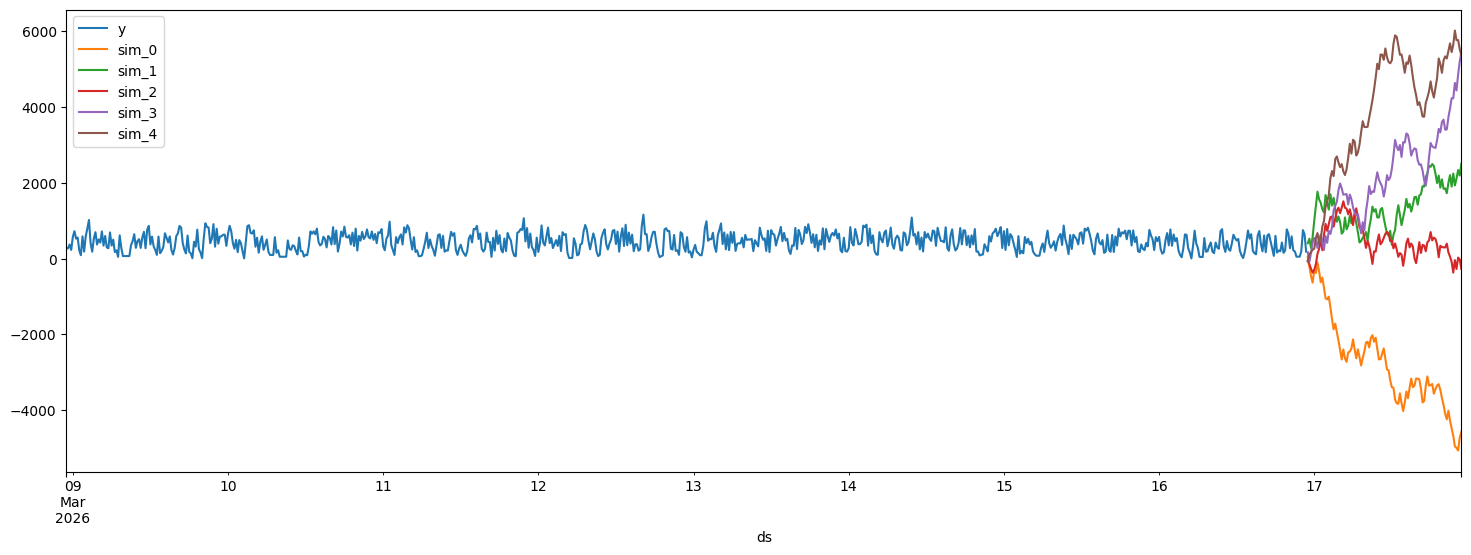

In [189]:
#visualiser ces sample paths

last_obs = resampled_df_autoarima["y"].iloc[-1]

def generate_sim_df(num_sims, h):
    steps = np.random.choice(residuals, size=(num_sims, h)) # num_sims arrays of arrays of size h
    sims = last_obs + steps.cumsum(axis=1)
    return pd.DataFrame({
        f"sim_{i}": sim
        for (i, sim) in enumerate(sims)
    })


sim_df = generate_sim_df(num_sims=5, h=96).assign(
    unique_id="inariz steam",
    ds=lambda x: resampled_df_autoarima["ds"].max() + (1 + x.index)*pd.Timedelta("15min"),
)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

resampled_df_autoarima.plot(x="ds", y="y", ax=ax)
for sim in range(5):
    sim_df.plot(x="ds", y=f"sim_{sim}", ax=ax)

<Axes: xlabel='ds'>

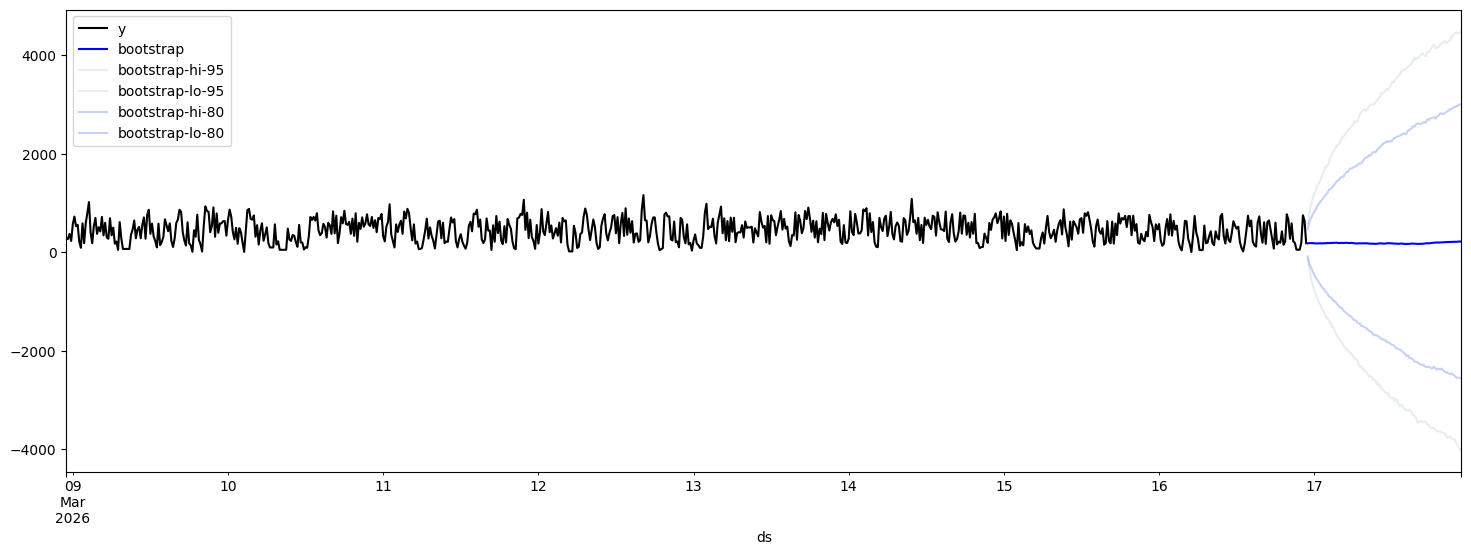

In [190]:
# calcul et plot des prediction intervals par cette procédure

raw_df = generate_sim_df(num_sims=5000, h=96)
sim_df = raw_df.assign(**{
    "unique_id": "inariz steam",
    "ds": resampled_df_autoarima["ds"].max() + (1 + raw_df.index)*pd.Timedelta("15min"),
    "bootstrap": raw_df.mean(axis="columns"),
    "bootstrap-lo-95": raw_df.quantile(0.025, axis="columns"),
    "bootstrap-lo-80": raw_df.quantile(0.1, axis="columns"),
    "bootstrap-hi-80": raw_df.quantile(0.9, axis="columns"),
    "bootstrap-hi-95": raw_df.quantile(0.975, axis="columns"),
})

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

resampled_df_autoarima.plot(x="ds", y="y", ax=ax, color="black")
sim_df.plot(x="ds", y="bootstrap", color="blue", ax=ax)
sim_df.plot(x="ds", y="bootstrap-hi-95", color="lightsteelblue", alpha=0.3, ax=ax)
sim_df.plot(x="ds", y="bootstrap-lo-95", color="lightsteelblue", alpha=0.3, ax=ax)
sim_df.plot(x="ds", y="bootstrap-hi-80", color="royalblue", alpha=0.3, ax=ax)
sim_df.plot(x="ds", y="bootstrap-lo-80", color="royalblue", alpha=0.3, ax=ax)

# plt fill_between does not work with Timestamps
# ax.fill_between(sim_df.index, sim_df["bootstrap-hi-95"], sim_df["bootstrap-lo-95"], color="lightsteelblue", alpha=0.3)
# ax.fill_between(sim_df.index, sim_df["bootstrap-hi-80"], sim_df["bootstrap-lo-80"], color="royalblue", alpha=0.3)


Pb avec le code ci-dessus : dépasse les contraintes phisiques [0, Pmax] de la chaudière

Première approche solution : rajouter un clipping avec la valeur min, sur 0

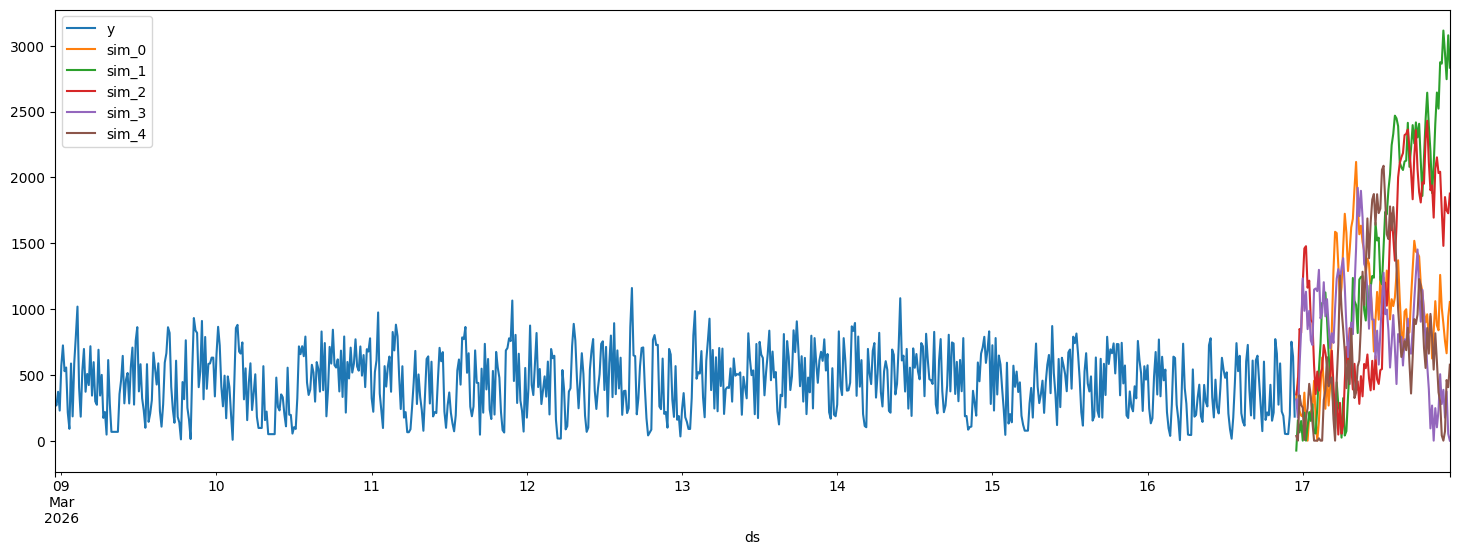

In [191]:
#visualiser ces sample paths

last_obs = resampled_df_autoarima["y"].iloc[-1]

def generate_sim_df(num_sims, h):
    steps = np.random.choice(residuals, size=(num_sims, h)) # num_sims arrays of arrays of size h
    # sims = last_obs + steps.cumsum(axis=1)
    # the classical formula is not suitable here, 
    # we need to adapt it for a priori knowledge about positivity
    sims = []
    for array in steps:
        sim = pd.DataFrame(array.T, columns = ["random_residuals"])
        sim.at[0 ,"bootstrapped_value"] = sim.at[0, "random_residuals"] + last_obs
        for i in range(1, h):
            sim.at[i, "bootstrapped_value"] = max(0, sim.at[i, "random_residuals"] + sim.at[i-1, "bootstrapped_value"])
        sims.append(sim["bootstrapped_value"].to_numpy())

    return pd.DataFrame({
        f"sim_{i}": sim
        for (i, sim) in enumerate(sims)
    })


sim_df = generate_sim_df(num_sims=5, h=96).assign(
    unique_id="inariz steam",
    ds=lambda x: resampled_df_autoarima["ds"].max() + (1 + x.index)*pd.Timedelta("15min"),
)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

resampled_df_autoarima.plot(x="ds", y="y", ax=ax)
for sim in range(5):
    sim_df.plot(x="ds", y=f"sim_{sim}", ax=ax)

<Axes: xlabel='ds'>

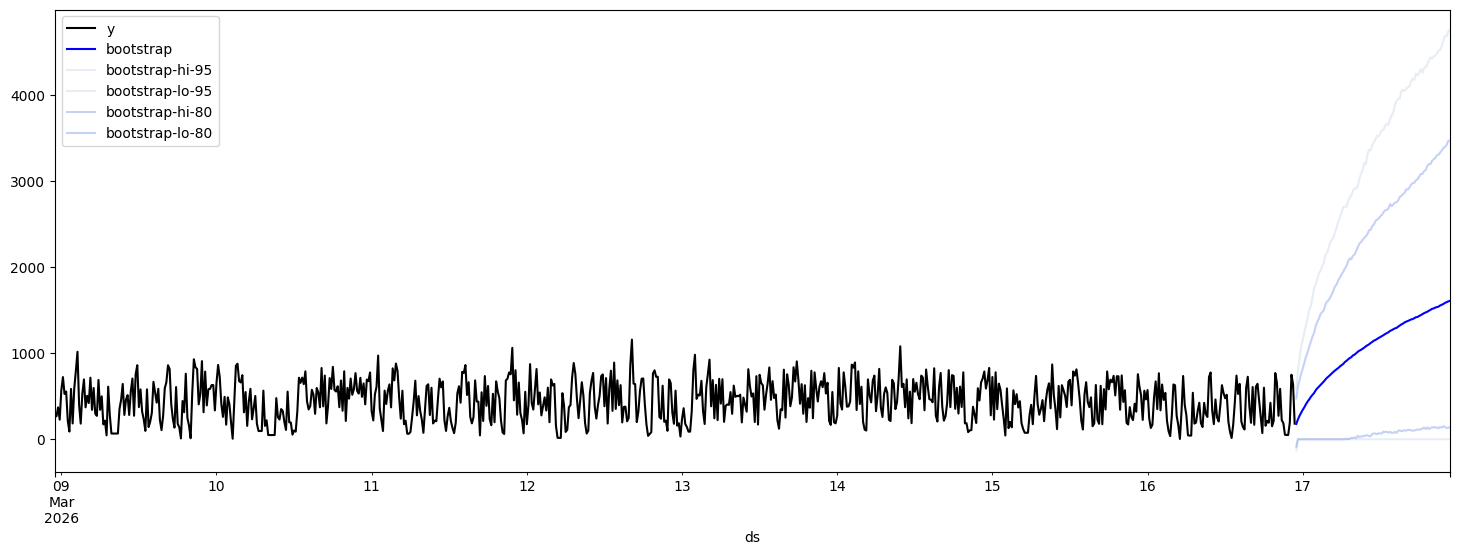

In [192]:
# calcul et plot des prediction intervals par cette procédure

raw_df = generate_sim_df(num_sims=5000, h=96)
sim_df = raw_df.assign(**{
    "unique_id": "inariz steam",
    "ds": resampled_df_autoarima["ds"].max() + (1 + raw_df.index)*pd.Timedelta("15min"),
    "bootstrap": raw_df.mean(axis="columns"),
    "bootstrap-lo-95": raw_df.quantile(0.025, axis="columns"),
    "bootstrap-lo-80": raw_df.quantile(0.1, axis="columns"),
    "bootstrap-hi-80": raw_df.quantile(0.9, axis="columns"),
    "bootstrap-hi-95": raw_df.quantile(0.975, axis="columns"),
})

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

resampled_df_autoarima.plot(x="ds", y="y", ax=ax, color="black")
sim_df.plot(x="ds", y="bootstrap", color="blue", ax=ax)
sim_df.plot(x="ds", y="bootstrap-hi-95", color="lightsteelblue", alpha=0.3, ax=ax)
sim_df.plot(x="ds", y="bootstrap-lo-95", color="lightsteelblue", alpha=0.3, ax=ax)
sim_df.plot(x="ds", y="bootstrap-hi-80", color="royalblue", alpha=0.3, ax=ax)
sim_df.plot(x="ds", y="bootstrap-lo-80", color="royalblue", alpha=0.3, ax=ax)

# plt fill_between does not work with Timestamps
# ax.fill_between(sim_df.index, sim_df["bootstrap-hi-95"], sim_df["bootstrap-lo-95"], color="lightsteelblue", alpha=0.3)
# ax.fill_between(sim_df.index, sim_df["bootstrap-hi-80"], sim_df["bootstrap-lo-80"], color="royalblue", alpha=0.3)


Meilleure approche : basculer sur une modélisation sur une valeur transformée, avec fonction logit

## Bounded-logit ARIMA bootstrap (inside [0, P_MAX])

On transforme `y` via une logit bornée sur `[0, P_MAX]`, on ajuste ARIMA sur cette échelle,
on bootstrap les résidus sur cette échelle, puis on inverse la transformation.
Ainsi, tous les chemins simulés et intervalles restent dans les bornes physiques.


Simulated range = [0.0000, 1159.3111] within [0.0, 1159.3110940746044]


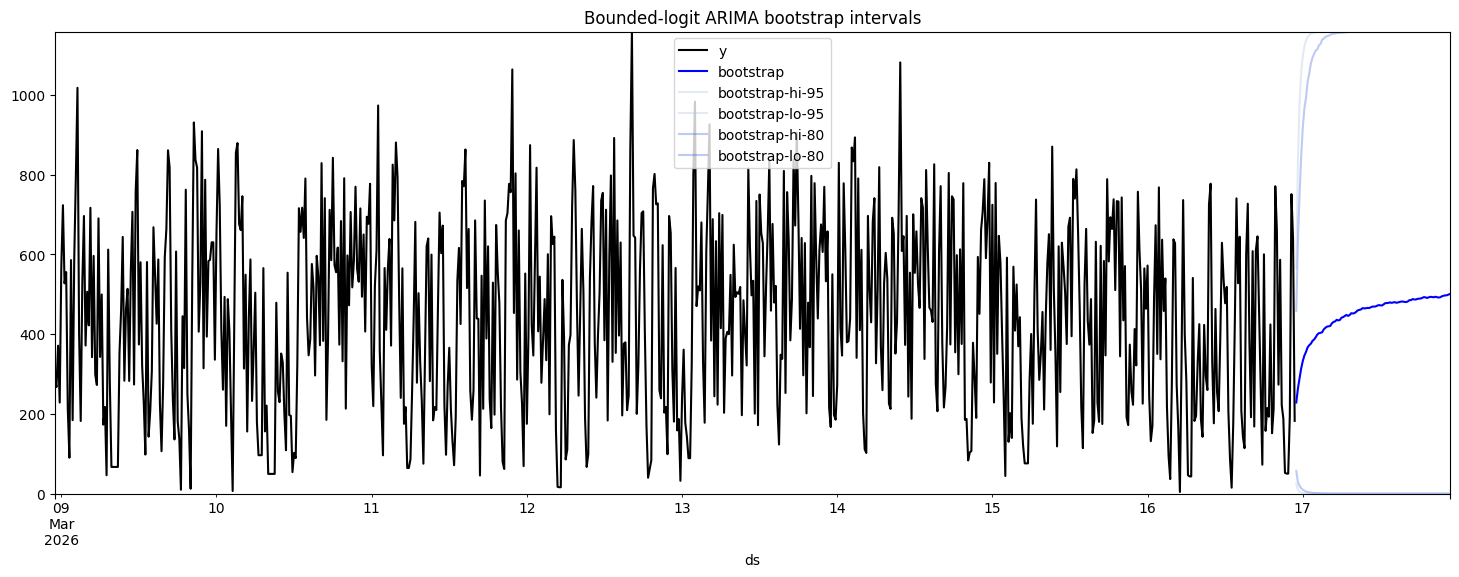

In [195]:
# Bounded-logit bootstrap: all simulated values stay in [Y_MIN, P_MAX]
# Set P_MAX to your known equipment rating.

Y_MIN = 0.0
P_MAX = float(resampled_df_autoarima["y"].max())  # TODO: replace with true known power rating
H = 96
N_SIMS = 5000
RNG_SEED = 42
EPS = 1e-6

if P_MAX <= Y_MIN:
    raise ValueError("P_MAX must be strictly greater than Y_MIN")

rng = np.random.default_rng(RNG_SEED)

# 1) Transform target to bounded-logit scale
series_y = resampled_df_autoarima["y"].astype(float).clip(Y_MIN + EPS, P_MAX - EPS)
y_logit = np.log((series_y - Y_MIN) / (P_MAX - series_y))

df_logit = resampled_df_autoarima[["unique_id", "ds"]].copy()
df_logit["y"] = y_logit

# 2) Fit ARIMA on transformed scale
models_logit = [AutoARIMA(stepwise=False, alias="search_logit")]
sf_logit = StatsForecast(models=models_logit, freq="15min", n_jobs=-1)
sf_logit.fit(df=df_logit)

_ = sf_logit.forecast(df=df_logit, h=H, fitted=True)
insample_logit = sf_logit.forecast_fitted_values()
residuals_logit = (insample_logit["y"] - insample_logit["search_logit"]).dropna().to_numpy()

if residuals_logit.size == 0:
    raise ValueError("No residuals available for bootstrap in logit space")

last_obs_logit = float(df_logit["y"].iloc[-1])


def inverse_bounded_logit(z, low, high):
    return low + (high - low) / (1.0 + np.exp(-z))


# 3) Bootstrap sample paths in transformed space, then inverse-transform
steps = rng.choice(residuals_logit, size=(N_SIMS, H), replace=True)
sims_logit = last_obs_logit + steps.cumsum(axis=1)
sims_bounded = inverse_bounded_logit(sims_logit, Y_MIN, P_MAX)

raw_df_bounded = pd.DataFrame({f"sim_{i}": sims_bounded[i] for i in range(N_SIMS)}).T.T
sim_df_bounded = raw_df_bounded.assign(
    unique_id="inariz steam",
    ds=lambda x: resampled_df_autoarima["ds"].max() + (1 + x.index) * pd.Timedelta("15min"),
    bootstrap=raw_df_bounded.mean(axis="columns"),
    **{
        "bootstrap-lo-95": raw_df_bounded.quantile(0.025, axis="columns"),
        "bootstrap-lo-80": raw_df_bounded.quantile(0.10, axis="columns"),
        "bootstrap-hi-80": raw_df_bounded.quantile(0.90, axis="columns"),
        "bootstrap-hi-95": raw_df_bounded.quantile(0.975, axis="columns"),
    },
)

# 4) Quick diagnostics: should always be within bounds
sim_min = float(raw_df_bounded.min().min())
sim_max = float(raw_df_bounded.max().max())
print(f"Simulated range = [{sim_min:.4f}, {sim_max:.4f}] within [{Y_MIN}, {P_MAX}]")

# 5) Plot intervals
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))
resampled_df_autoarima.plot(x="ds", y="y", ax=ax, color="black")
sim_df_bounded.plot(x="ds", y="bootstrap", color="blue", ax=ax)
sim_df_bounded.plot(x="ds", y="bootstrap-hi-95", color="lightsteelblue", alpha=0.35, ax=ax)
sim_df_bounded.plot(x="ds", y="bootstrap-lo-95", color="lightsteelblue", alpha=0.35, ax=ax)
sim_df_bounded.plot(x="ds", y="bootstrap-hi-80", color="royalblue", alpha=0.35, ax=ax)
sim_df_bounded.plot(x="ds", y="bootstrap-lo-80", color="royalblue", alpha=0.35, ax=ax)
ax.set_title("Bounded-logit ARIMA bootstrap intervals")
ax.set_ylim(Y_MIN, P_MAX)
plt.show()

